In [28]:
!pip install rasterio

   ---------------------------------------- 0.0/25.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/25.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/25.5 MB 217.9 kB/s eta 0:01:57
   ---------------------------------------- 0.1/25.5 MB 375.8 kB/s eta 0:01:08
   ---------------------------------------- 0.1/25.5 MB 435.7 kB/s eta 0:00:59
   ---------------------------------------- 0.1/25.5 MB 655.8 kB/s eta 0:00:39
   ---------------------------------------- 0.2/25.5 MB 696.3 kB/s eta 0:00:37
   ---------------------------------------- 0.2/25.5 MB 801.7 kB/s eta 0:00:32
   ---------------------------------------- 0.3/25.5 MB 842.9 kB/s eta 0:00:30
    --------------------------------------- 0.3/25.5 MB 912.8 kB/s eta 0:00:28
    --------------------------------------- 0.3/25.5 MB 912.8 kB/s eta 0:00:28
    --------------------------------------- 0.4/25.5 MB 836.4 kB/s eta 0:00:30
    --------------------------------------- 0.4/25.5 MB 867.4 kB/s eta

## Import the essential libraries

In [30]:
# Essential and common packages
import os
import glob

# Read and visualize the raster data
import rasterio
from rasterio.plot import show

# Plots and bars
import matplotlib.pyplot as plt
import seaborn as sns

# Computation library
import numpy as np

# Tensorflow for building the resnet50 model
import tensorflow.python.keras as k
import tensorflow as tf
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.initializers import random_uniform, glorot_uniform
from tensorflow.keras.models import Model

# Sklearn for confusion matrix
import itertools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For visualization of plots without plt.show()
%matplotlib inline


## Define the required variable

In [31]:
dataset_url = r"C:\Users\hp\Downloads\EuroSAT\2750"
batch_size = 32
img_height = 64
img_width = 64
validation_split=0.2
rescale=1.0/255


## Data preparation

In [32]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(validation_split=validation_split, rescale=rescale)
dataset = tf.keras.preprocessing.image_dataset_from_directory(dataset_url, image_size=(img_height, img_width), batch_size=batch_size)



Found 27000 files belonging to 10 classes.


In [33]:
train_dataset = datagen.flow_from_directory(batch_size=batch_size,
                                           directory=dataset_url,
                                           shuffle=True,
                                           target_size=(img_height, img_width),
                                           subset="training",
                                           class_mode='categorical')


Found 21600 images belonging to 10 classes.


In [34]:

test_dataset = datagen.flow_from_directory(batch_size=batch_size,
                                           directory=dataset_url,
                                           shuffle=True,
                                           target_size=(img_height, img_width),
                                           subset="validation",
                                           class_mode='categorical')


Found 5400 images belonging to 10 classes.


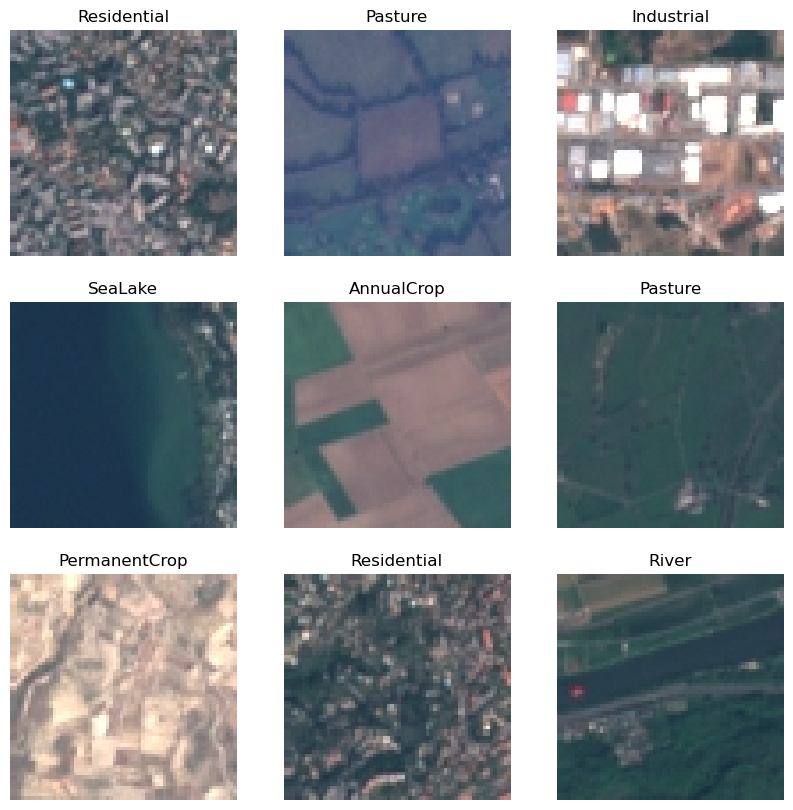

In [35]:
class_names = dataset.class_names
plt.figure(figsize=(10, 10))
for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


## ResNet50 Model building

In [36]:
def identity_block(X, f, filters, training=True, initializer=random_uniform):
    """
    Implementation of the identity block as defined in Figure 4
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    training -- True: Behave in training mode
                False: Behave in inference mode
    initializer -- to set up the initial weights of a layer. Equals to random uniform initializer
    
    Returns:
    X -- output of the identity block, tensor of shape (n_H, n_W, n_C)
    """
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value.
    X_shortcut = X
    cache = []
    # First component of main path
    X = Conv2D(filters = F1, kernel_size = 1, strides = (1, 1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training) # Default axis
    X = Activation('relu')(X)
    
    # Second component of main path (≈3 lines)
    X = Conv2D(filters = F2, kernel_size = (f, f), strides = (1, 1), padding = 'same', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = Conv2D(filters = F3, kernel_size = (1, 1), strides = (1, 1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    X = Add()([X_shortcut, X])
    X = X = Activation('relu')(X, training = training)

    return X

In [37]:
def convolutional_block(X, f, filters, s = 2, training=True, initializer=glorot_uniform):
    """
    Implementation of the convolutional block as defined in Figure 4
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    s -- Integer, specifying the stride to be used
    training -- True: Behave in training mode
                False: Behave in inference mode
    initializer -- to set up the initial weights of a layer. Equals to Glorot uniform initializer, 
                   also called Xavier uniform initializer.
    
    Returns:
    X -- output of the convolutional block, tensor of shape (n_H, n_W, n_C)
    """
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value
    X_shortcut = X


    ##### MAIN PATH #####
    
    # First component of main path glorot_uniform(seed=0)
    X = Conv2D(filters = F1, kernel_size = 1, strides = (s, s), padding='valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=training)
    X = Activation('relu')(X)

    
    # Second component of main path (≈3 lines)
    X = Conv2D(F2, (f, f), strides = (1, 1), padding = 'same', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = Conv2D(F3, (1, 1), strides = (1, 1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)

    ##### SHORTCUT PATH #### (≈2 lines)
    X_shortcut = Conv2D(F3, (1, 1), strides = (s, s), padding = 'valid', kernel_initializer = initializer(seed=0))(X_shortcut)
    X_shortcut = BatchNormalization(axis = 3)(X_shortcut, training = training)

    # Final step: Add shortcut value to main path (Use this order [X, X_shortcut]), and pass it through a RELU activation
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    
    return X



In [38]:
def ResNet50(input_shape = (64, 64, 3), classes = 6):
    """
    Stage-wise implementation of the architecture of the popular ResNet50:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> FLATTEN -> DENSE 

    Arguments:
    input_shape -- shape of the images of the dataset
    classes -- integer, number of classes

    Returns:
    model -- a Model() instance in Keras
    """
    
    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)

    
    # Zero-Padding
    X = ZeroPadding2D((3, 3))(X_input)
    
    # Stage 1
    X = Conv2D(64, (7, 7), strides = (2, 2), kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f = 3, filters = [64, 64, 256], s = 1)
    X = identity_block(X, 3, [64, 64, 256])
    X = identity_block(X, 3, [64, 64, 256])

    # Stage 3 (≈4 lines)
    X = convolutional_block(X, f = 3, filters = [128, 128, 512], s = 2)
    X = identity_block(X, 3, [128, 128, 512])
    X = identity_block(X, 3, [128, 128, 512])
    X = identity_block(X, 3, [128, 128, 512])

    # Stage 4 (≈6 lines)
    X = convolutional_block(X, f = 3, filters = [256, 256, 1024], s = 2)
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])

    # Stage 5 (≈3 lines)
    X = convolutional_block(X, f = 3, filters = [512, 512, 2048], s = 2)
    X = identity_block(X, 3, [512, 512, 2048])
    X = identity_block(X, 3, [512, 512, 2048])

    # AVGPOOL (≈1 line). Use "X = AveragePooling2D(...)(X)"
    X = AveragePooling2D(pool_size = (2, 2), name = 'avg_pool')(X)
    

    # output layer
    X = Flatten()(X)
    X = Dense(classes, activation='softmax', kernel_initializer = glorot_uniform(seed=0))(X)
    
    
    # Create model
    model = Model(inputs = X_input, outputs = X)

    return model

    

## Model train

In [39]:
model = ResNet50(input_shape=(64,64,3), classes=10)

In [40]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [41]:
# please increase the epoch for higher accuracy (epochs=100)
history = model.fit(train_dataset, validation_data=test_dataset, epochs=20, batch_size=32)


Epoch 1/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 1100s 1s/step - accuracy: 0.4425 - loss: 1.8549 - val_accuracy: 0.3035 - val_loss: 3.6727
Epoch 2/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 4737s 7s/step - accuracy: 0.6302 - loss: 1.1295 - val_accuracy: 0.6111 - val_loss: 1.0953
Epoch 3/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 800s 1s/step - accuracy: 0.7172 - loss: 0.8569 - val_accuracy: 0.1550 - val_loss: 99.2640
Epoch 4/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step - accuracy: 0.6969 - loss: 0.9495 - val_accuracy: 0.5274 - val_loss: 1.9737
Epoch 5/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 769s 1s/step - accuracy: 0.7151 - loss: 1.0218 - val_accuracy: 0.3078 - val_loss: 5.7536
Epoch 6/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 700s 1s/step - accuracy: 0.7402 - loss: 0.7912 - val_accuracy: 0.7474 - val_loss: 0.7070
Epoch 7/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 611s 906ms/step - accuracy: 0.7874 - loss: 0.6593 - val_accuracy: 0.7933 - val_loss: 0.5773
Epoch 8/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 644s 954ms/step - accuracy: 0.8125 - loss: 0.6288 -

In [44]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


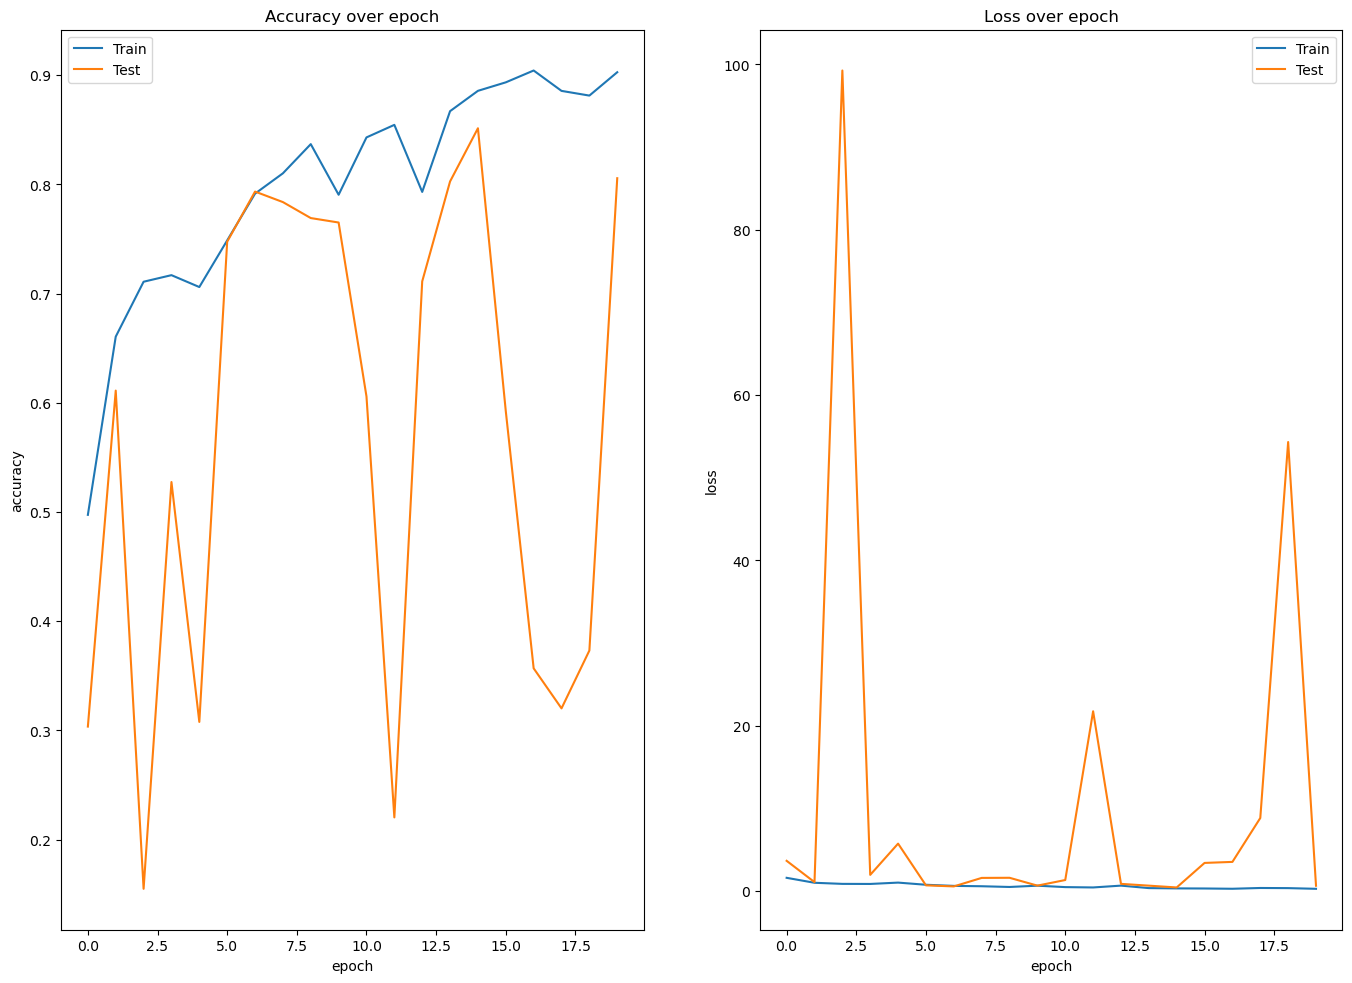

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16.53, 11.69))
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xlabel('epoch')
ax1.set_ylabel('accuracy')
ax1.set_title('Accuracy over epoch')
ax1.legend(['Train', 'Test'], loc='upper left')

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
ax2.set_title('Loss over epoch')
ax2.legend(['Train', 'Test'], loc="upper right")


#### 📈 Accuracy Plot

- **Blue Line (Train Accuracy)**:  
  Shows a consistent upward trend, indicating effective learning on the training set.  
  ✅ Reaches above 90%.

- **Orange Line (Test Accuracy)**:  
  Fluctuates sharply between epochs.  
  ❌ Ranges from 20% to 90% – indicating **instability** and **poor generalization**.

**🔍 Interpretation**:
- Likely **overfitting**: model memorizes training data but fails on validation set.
- Potential **data imbalance** or **validation leakage**.
- Could be influenced by **small batch stats** (e.g., BatchNorm instability).

#### 📉 Loss Plot

- **Blue Line (Train Loss)**:  
  Smooth and decreasing – model minimizing error on training set.

- **Orange Line (Test Loss)**:  
  Highly erratic with extreme spikes (some >100).

**🔍 Interpretation**:
- Severe **numerical instability** or **exploding gradients**.
- Mismatch in batch size or class presence during validation.
- Model sensitive to underrepresented or similar-looking classes.

---

In [47]:
y_pred = []  # store predicted labels
y_true = []  # store true labels

# iterate over the dataset
for i, (image_batch, label_batch) in enumerate(test_dataset):   # use dataset.unbatch() with repeat
    # append true labels
    y_true.append(label_batch)
    # compute predictions
    preds = model.predict(image_batch)
    # append predicted labels
    y_pred.append(np.argmax(preds, axis =  1))
    if i==300:
        break

# convert the true and predicted labels into tensors
correct_labels = tf.concat([item for item in y_true], axis = 0)
correct_labels = np.argmax(correct_labels, axis=1)
predicted_labels = tf.concat([item for item in y_pred], axis = 0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [48]:
cm = confusion_matrix(correct_labels, predicted_labels)
cm

array([[ 628,   10,  171,   33,   14,    9,  126,    3,   67,   14],
       [   0, 1061,   10,    0,    0,    2,    0,    0,    2,    3],
       [   0,   15,  987,    3,   18,    2,    1,   50,    1,    0],
       [   3,    0,   28,  670,  117,    2,   16,   44,   25,    0],
       [   0,    0,    0,    0,  890,    0,    0,   13,    0,    0],
       [   5,   82,   44,   22,    0,  423,   75,    6,   45,    2],
       [   4,    0,  327,   10,   41,    0,  360,  121,   17,    0],
       [   0,    0,    0,    0,   24,    0,    0, 1048,    0,    0],
       [   6,   13,   44,   90,   11,    4,   13,    6,  683,    2],
       [   0,   16,    2,    0,    0,    3,    0,    0,    5, 1032]],
      dtype=int64)

In [49]:
def plot_confusion_matrix(cm, classes,
                        normalize=False,
                        title='Confusion matrix',
                        figsize=(10, 10),
                        cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[ 628   10  171   33   14    9  126    3   67   14]
 [   0 1061   10    0    0    2    0    0    2    3]
 [   0   15  987    3   18    2    1   50    1    0]
 [   3    0   28  670  117    2   16   44   25    0]
 [   0    0    0    0  890    0    0   13    0    0]
 [   5   82   44   22    0  423   75    6   45    2]
 [   4    0  327   10   41    0  360  121   17    0]
 [   0    0    0    0   24    0    0 1048    0    0]
 [   6   13   44   90   11    4   13    6  683    2]
 [   0   16    2    0    0    3    0    0    5 1032]]


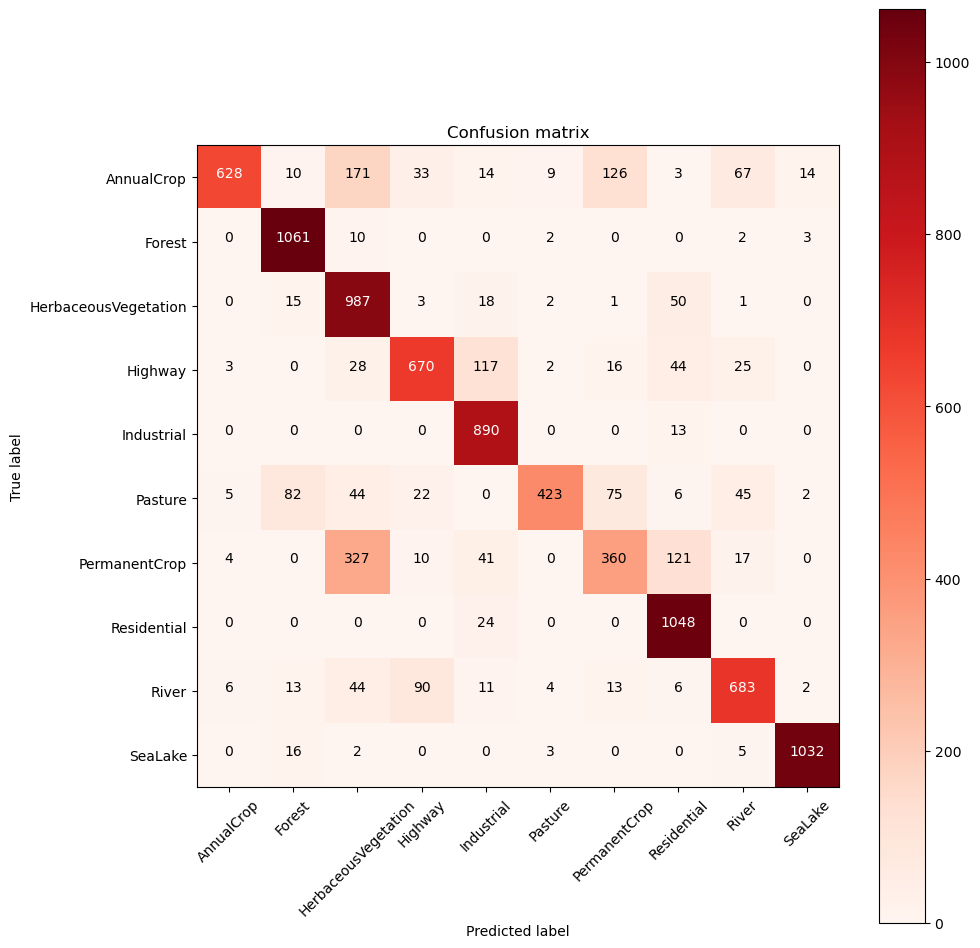

In [50]:
plot_confusion_matrix(cm, train_dataset.class_indices, cmap='Reds')

This confusion matrix illustrates model predictions versus true labels for the 10 land cover classes.

| **Class**             | **Key Observations**                                                                 |
|------------------------|--------------------------------------------------------------------------------------|
| **AnnualCrop**         | Confused with `HerbaceousVegetation` (171) and `Pasture` (126).                     |
| **Forest**             | Almost perfect predictions (1061 correct).                                          |
| **HerbaceousVegetation** | Minor confusion with `AnnualCrop` and `Pasture`.                                |
| **Highway**            | Strongly confused with `Industrial` (117) – structural similarity.                  |
| **Industrial**         | Well predicted (890 correct), some mix-up with `Residential`.                       |
| **Pasture**            | Confusion with `HerbaceousVegetation` (44) and `PermanentCrop` (75).                |
| **PermanentCrop**      | Confused with `Pasture` (121) and `HerbaceousVegetation` (327).                     |
| **Residential**        | Excellent performance (1048 correct).                                               |
| **River**              | Confused with `HerbaceousVegetation` (44) and `Highway` (90).                       |
| **SeaLake**            | Very high accuracy (1032 correct).  

#### ✅ Summary

- **Strong Classes**: `Forest`, `Residential`, `SeaLake`
- **Confused Classes**: `AnnualCrop`, `Pasture`, `PermanentCrop`, `HerbaceousVegetation`
- Likely causes:
  - **Spectral similarity** in RGB bands
  - **Class imbalance**
  - **Natural semantic overlap** between vegetation types